# Phase A: Data Understanding & Data Quality

Run `python -m src.preprocessing.load_data` from the project root first to confirm all CSVs are in place.

In [37]:
import sys
sys.path.append('..')

from src.preprocessing.load_data import load_all_tables

tables = load_all_tables()

[customers             ] rows= 99,441 cols= 5 exact_dupes=    0 cols_with_missing= 0 | duplicate rows on grain key ['customer_id']: 0
[orders                ] rows= 99,441 cols= 8 exact_dupes=    0 cols_with_missing= 3 | duplicate rows on grain key ['order_id']: 0
[order_items           ] rows=112,650 cols= 7 exact_dupes=    0 cols_with_missing= 0 | duplicate rows on grain key ['order_id', 'order_item_id']: 0
[products              ] rows= 32,951 cols= 9 exact_dupes=    0 cols_with_missing= 8 | duplicate rows on grain key ['product_id']: 0
[payments              ] rows=103,886 cols= 5 exact_dupes=    0 cols_with_missing= 0
[reviews               ] rows= 99,224 cols= 7 exact_dupes=    0 cols_with_missing= 2
[sellers               ] rows=  3,095 cols= 4 exact_dupes=    0 cols_with_missing= 0 | duplicate rows on grain key ['seller_id']: 0
[geolocation           ] rows=1,000,163 cols= 5 exact_dupes=261831 cols_with_missing= 0
[category_translation  ] rows=     71 cols= 2 exact_dupes=    0 

In [38]:
customers = tables['customers']
orders = tables['orders']
order_items = tables['order_items']
products = tables['products']
payments = tables['payments']
reviews = tables['reviews']
sellers = tables['sellers']
geolocation = tables['geolocation']
category_translation = tables['category_translation']

print("All tables extracted as individual variables.")

All tables extracted as individual variables.


In [39]:
# TODO next:
# - missing value audit per table
# - duplicate investigation
# - order status breakdown (cancelled/unavailable orders)
# - dtype conversions where needed

In [40]:
print(orders['order_status'].value_counts())
print("\nPercentage breakdown:")
print((orders['order_status'].value_counts(normalize=True) * 100).round(2))

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Percentage breakdown:
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


## Decision: Order Status Filtering
- 97% of orders are `delivered`. 
- For revenue/AOV/delivery-performance EDA, we will filter to `order_status == 'delivered'`.
- Canceled/unavailable orders (1.24% combined) will be retained as a customer-level feature (count of cancelled orders) in Phase C, not dropped entirely.

In [41]:
for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        pct = (missing / len(df) * 100).round(2)
        print(f"\n{name}:")
        for col in missing.index:
            print(f"  {col}: {missing[col]} missing ({pct[col]}%)")


orders:
  order_approved_at: 160 missing (0.16%)
  order_delivered_carrier_date: 1783 missing (1.79%)
  order_delivered_customer_date: 2965 missing (2.98%)

products:
  product_category_name: 610 missing (1.85%)
  product_name_lenght: 610 missing (1.85%)
  product_description_lenght: 610 missing (1.85%)
  product_photos_qty: 610 missing (1.85%)
  product_weight_g: 2 missing (0.01%)
  product_length_cm: 2 missing (0.01%)
  product_height_cm: 2 missing (0.01%)
  product_width_cm: 2 missing (0.01%)

reviews:
  review_comment_title: 87656 missing (88.34%)
  review_comment_message: 58247 missing (58.7%)


In [42]:
for name, df in tables.items():
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"{name}: {dupes} exact duplicate rows ({(dupes/len(df)*100):.2f}%)")

geolocation: 261831 exact duplicate rows (26.18%)


## Decision: Missing Value Handling

**orders (date columns):**
- `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` have small % missing.
- These are legitimately missing for orders that were canceled/unavailable before reaching that stage — NOT a data error.
- Decision: Leave as NaT (do not impute). Delivery-time features will only be computed for orders where these dates exist.

**products:**
- 610 rows (1.85%) missing `product_category_name` and related text/photo fields — likely products with incomplete listings.
- Decision: Fill `product_category_name` with `"unknown"` for EDA/segmentation purposes. Drop or flag these rows only if they materially affect specific analyses.
- 2 rows missing weight/dimensions — negligible; drop these 2 rows only when weight/dimension features are specifically needed.

**reviews:**
- `review_comment_title` (88%) and `review_comment_message` (59%) missing — expected, since most customers leave a score without writing text.
- Decision: Do NOT drop these rows (review_score is still valid). Only relevant for optional NLP phase, where we'll filter to rows with non-null comment text.

**geolocation:**
- 26% duplicate rows are expected (same zip-code prefix, multiple lat/long entries).
- Decision: Not a cleaning issue. Will deduplicate by zip prefix (using mean/median lat-long) only if geolocation is used for mapping/joins later.

In [43]:
import pandas as pd

date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(orders[date_cols].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


# Phase B: Exploratory Data Analysis & Business Insights

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(delivered_orders)}")

Delivered orders: 96478


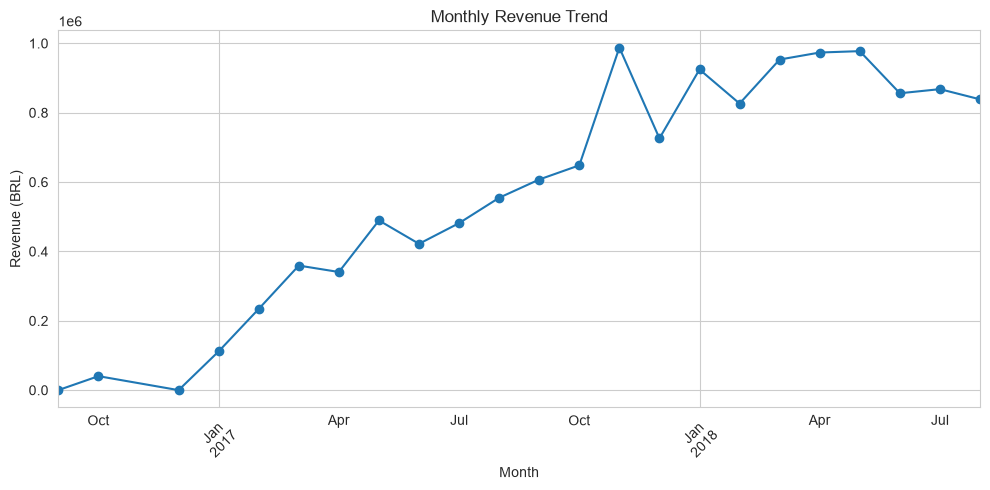

In [45]:
order_revenue = order_items.merge(delivered_orders[['order_id', 'order_purchase_timestamp']], on='order_id')
order_revenue['order_month'] = order_revenue['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = order_revenue.groupby('order_month')['price'].sum()

monthly_revenue.plot(kind='line', marker='o', title='Monthly Revenue Trend')
plt.ylabel('Revenue (BRL)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

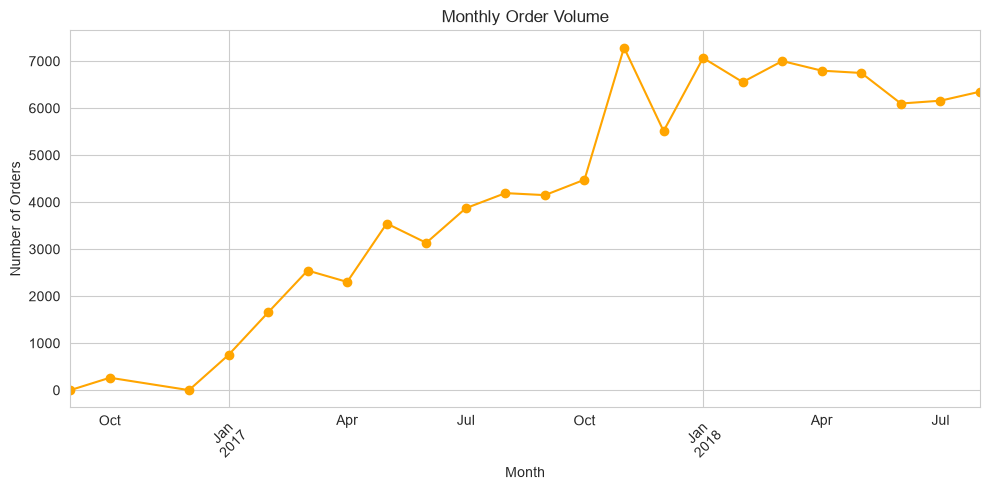

In [46]:
monthly_orders = delivered_orders.groupby(delivered_orders['order_purchase_timestamp'].dt.to_period('M')).size()

monthly_orders.plot(kind='line', marker='o', color='orange', title='Monthly Order Volume')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
order_totals = order_items.groupby('order_id')['price'].sum().reset_index()
order_totals = order_totals.merge(delivered_orders[['order_id']], on='order_id')

aov = order_totals['price'].mean()
print(f"Average Order Value: R$ {aov:.2f}")
print(order_totals['price'].describe())

Average Order Value: R$ 137.04
count    96478.000000
mean       137.041586
std        209.045198
min          0.850000
25%         45.900000
50%         86.575000
75%        149.900000
max      13440.000000
Name: price, dtype: float64


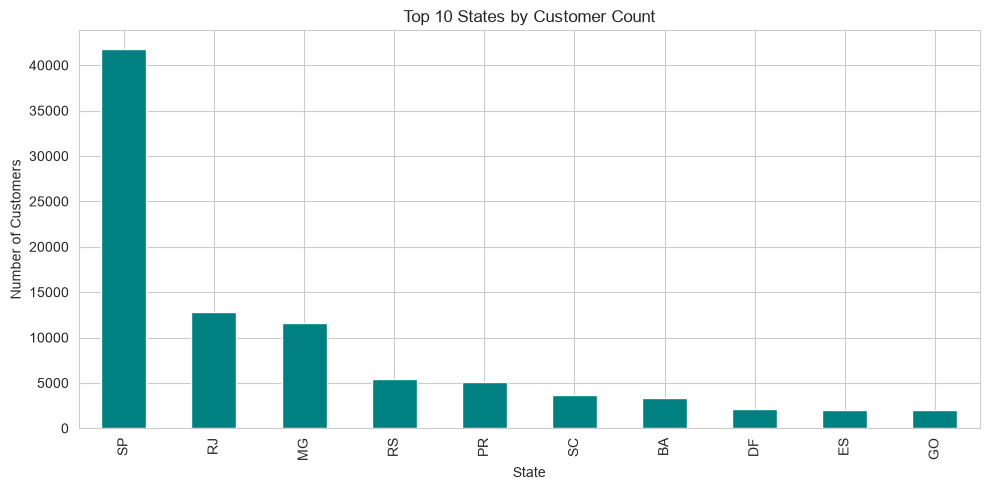

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [48]:
customer_state = customers['customer_state'].value_counts().head(10)

customer_state.plot(kind='bar', title='Top 10 States by Customer Count', color='teal')
plt.ylabel('Number of Customers')
plt.xlabel('State')
plt.tight_layout()
plt.show()

print(customer_state)

Top 10 categories by revenue:
product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

Bottom 10 categories by revenue:
product_category_name_english
fashio_female_clothing       2803.64
fashion_sport                2119.51
la_cuisine                   2054.99
arts_and_craftmanship        1814.01
diapers_and_hygiene          1567.59
flowers                      1110.04
home_comfort_2                760.27
cds_dvds_musicals             730.00
fashion_childrens_clothes     569.85
security_and_services         283.29
Name: price, dtype: float64


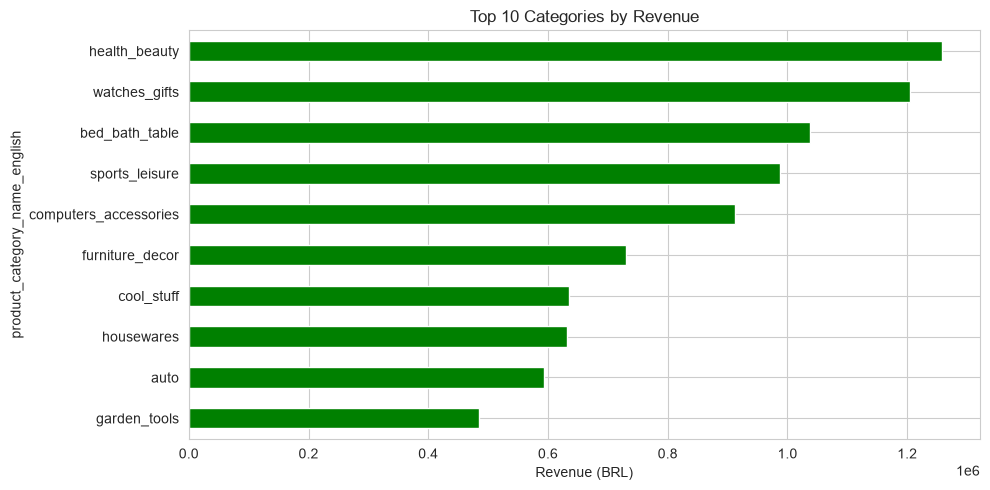

In [49]:
# Merge order_items with products to get category, then with translation for English names
items_with_cat = order_items.merge(products[['product_id', 'product_category_name']], on='product_id')
items_with_cat = items_with_cat.merge(category_translation, on='product_category_name', how='left')

category_revenue = items_with_cat.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)

print("Top 10 categories by revenue:")
print(category_revenue.head(10))

print("\nBottom 10 categories by revenue:")
print(category_revenue.tail(10))

category_revenue.head(10).plot(kind='barh', title='Top 10 Categories by Revenue', color='green')
plt.xlabel('Revenue (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


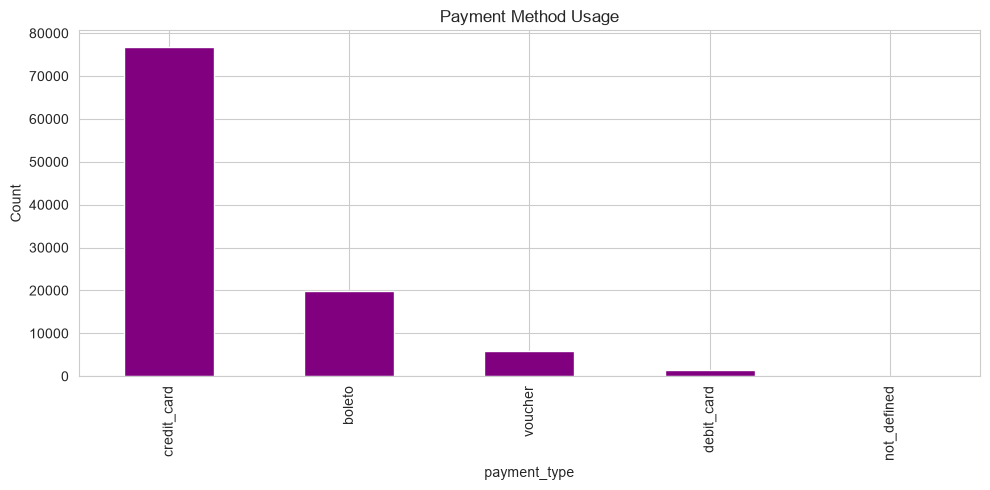


Installments distribution:
payment_installments
0        2
1    52546
2    12413
3    10461
4     7098
5     5239
6     3920
7     1626
8     4268
9      644
Name: count, dtype: int64


In [50]:
payment_type_counts = payments['payment_type'].value_counts()
print(payment_type_counts)

payment_type_counts.plot(kind='bar', title='Payment Method Usage', color='purple')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nInstallments distribution:")
print(payments['payment_installments'].value_counts().sort_index().head(10))

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


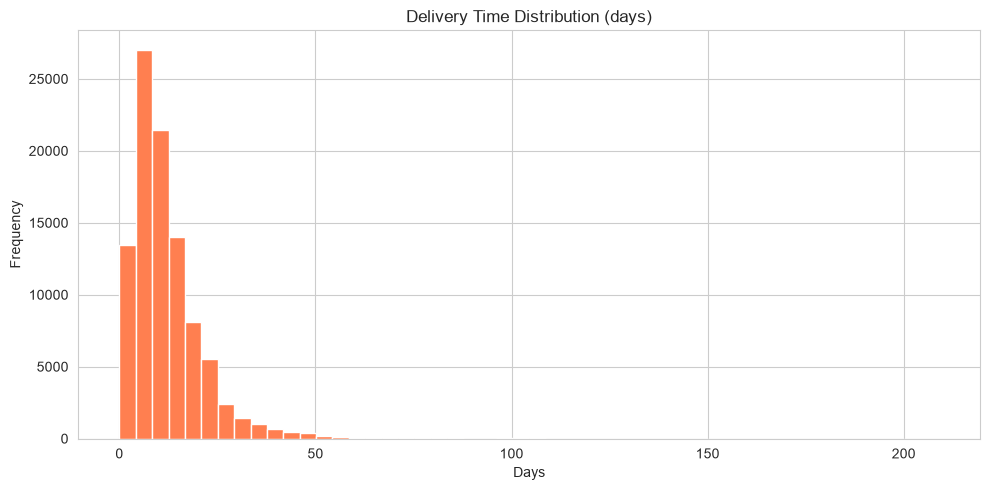


On-time delivery rate: 0.919


In [51]:
delivered_with_dates = delivered_orders.dropna(subset=['order_delivered_customer_date'])
delivered_with_dates['delivery_days'] = (
    delivered_with_dates['order_delivered_customer_date'] - delivered_with_dates['order_purchase_timestamp']
).dt.days

print(delivered_with_dates['delivery_days'].describe())

delivered_with_dates['delivery_days'].plot(kind='hist', bins=50, title='Delivery Time Distribution (days)', color='coral')
plt.xlabel('Days')
plt.tight_layout()
plt.show()

# On-time vs late delivery
delivered_with_dates['on_time'] = delivered_with_dates['order_delivered_customer_date'] <= delivered_with_dates['order_estimated_delivery_date']
print("\nOn-time delivery rate:", delivered_with_dates['on_time'].mean().round(3))

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


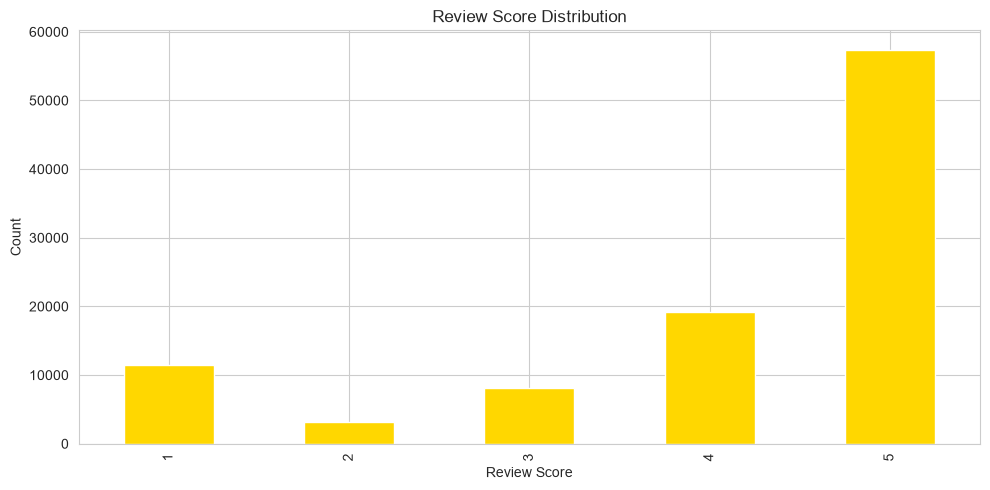

In [52]:
review_dist = reviews['review_score'].value_counts().sort_index()
print(review_dist)

review_dist.plot(kind='bar', title='Review Score Distribution', color='gold')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

count    93358.000000
mean         1.033420
std          0.209097
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
dtype: float64

Customers with more than 1 order: 2801
% repeat customers: 3.0


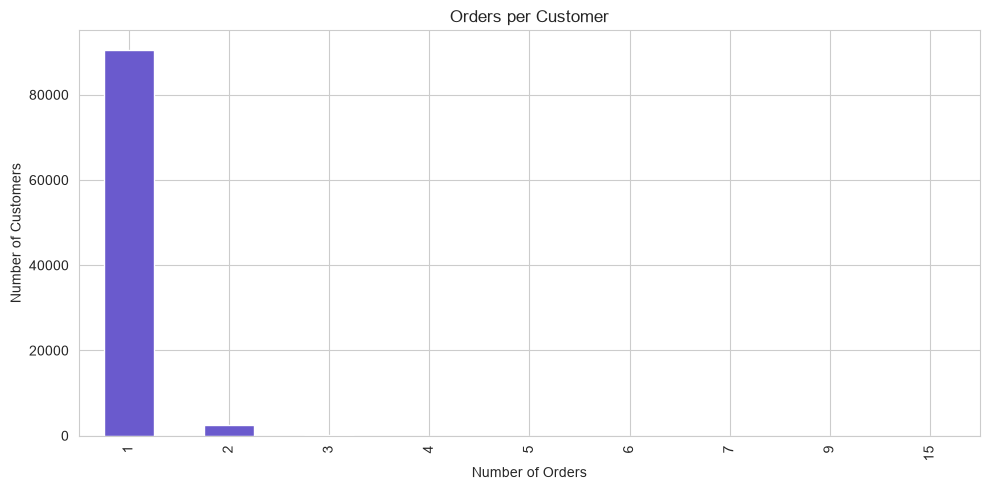

In [53]:
# How many orders does each unique customer place?
orders_with_customer = delivered_orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

purchase_freq = orders_with_customer.groupby('customer_unique_id').size()

print(purchase_freq.describe())
print("\nCustomers with more than 1 order:", (purchase_freq > 1).sum())
print("% repeat customers:", round((purchase_freq > 1).mean() * 100, 2))

purchase_freq.value_counts().sort_index().head(10).plot(kind='bar', title='Orders per Customer', color='slateblue')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [54]:
# Revenue concentration by customer
customer_revenue = order_totals.merge(orders_with_customer[['order_id', 'customer_unique_id']], on='order_id')
customer_revenue = customer_revenue.groupby('customer_unique_id')['price'].sum().sort_values(ascending=False)

cum_revenue = customer_revenue.cumsum() / customer_revenue.sum()
top_10pct_customers = int(len(cum_revenue) * 0.1)
print(f"Revenue share from top 10% of customers: {cum_revenue.iloc[top_10pct_customers]*100:.1f}%")

# Revenue concentration by category
cat_cum = category_revenue.sort_values(ascending=False).cumsum() / category_revenue.sum()
top_10pct_cats = max(1, int(len(cat_cum) * 0.1))
print(f"Revenue share from top 10% of categories: {cat_cum.iloc[top_10pct_cats]*100:.1f}%")

Revenue share from top 10% of customers: 41.1%
Revenue share from top 10% of categories: 55.2%


## Phase B Summary — Key Business Insights
- [Fill in: revenue trend observation, e.g. seasonal spike in Nov 2017]
- [Fill in: AOV value]
- [Fill in: top-performing states/categories]
- [Fill in: % repeat customers — likely low, common for e-commerce]
- [Fill in: on-time delivery rate]
- [Fill in: revenue concentration finding]

# Phase C: Customer Feature Engineering (RFM + Behavioral Features)

In [55]:
# Reference date = one day after the last purchase in the dataset (standard RFM practice)
reference_date = orders_with_customer['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Reference date for Recency calculation:", reference_date)

rfm = orders_with_customer.groupby('customer_unique_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    last_purchase_date=('order_purchase_timestamp', 'max')
).reset_index()

# Monetary: total spend per customer (from order_totals + customer mapping)
monetary = customer_revenue.reset_index()
monetary.columns = ['customer_unique_id', 'monetary']

rfm = rfm.merge(monetary, on='customer_unique_id', how='left')

print(rfm.shape)
rfm.head()

Reference date for Recency calculation: 2018-08-30 15:00:37
(93358, 5)


,customer_unique_id,recency_days,frequency,last_purchase_date,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,2018-05-10 10:56:27,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,2018-05-07 11:11:27,18.90
2,0000f46a3911fa3c0805444483337064,537,1,2017-03-10 21:05:03,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,2017-10-12 20:29:41,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,2017-11-14 19:45:42,180.00


In [56]:
order_item_counts = order_items.groupby('order_id').size().reset_index(name='n_items')
order_value = order_items.groupby('order_id')['price'].sum().reset_index(name='order_value')

order_details = order_value.merge(order_item_counts, on='order_id')
order_details = order_details.merge(orders_with_customer[['order_id', 'customer_unique_id']], on='order_id')

customer_order_stats = order_details.groupby('customer_unique_id').agg(
    avg_order_value=('order_value', 'mean'),
    avg_items_per_order=('n_items', 'mean')
).reset_index()

rfm = rfm.merge(customer_order_stats, on='customer_unique_id', how='left')
rfm.head()

,customer_unique_id,recency_days,frequency,last_purchase_date,monetary,avg_order_value,avg_items_per_order
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,2018-05-10 10:56:27,129.90,129.90,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,2018-05-07 11:11:27,18.90,18.90,1.0
2,0000f46a3911fa3c0805444483337064,537,1,2017-03-10 21:05:03,69.00,69.00,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,2017-10-12 20:29:41,25.99,25.99,1.0
4,0004aac84e0df4da2b147fca70cf8255,288,1,2017-11-14 19:45:42,180.00,180.00,1.0


In [57]:
freight_by_order = order_items.groupby('order_id')['freight_value'].sum().reset_index()
freight_by_order = freight_by_order.merge(orders_with_customer[['order_id', 'customer_unique_id']], on='order_id')

avg_freight = freight_by_order.groupby('customer_unique_id')['freight_value'].mean().reset_index()
avg_freight.columns = ['customer_unique_id', 'avg_freight_cost']

rfm = rfm.merge(avg_freight, on='customer_unique_id', how='left')
rfm.head()

,customer_unique_id,recency_days,frequency,last_purchase_date,monetary,avg_order_value,avg_items_per_order,avg_freight_cost
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,2018-05-10 10:56:27,129.90,129.90,1.0,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,2018-05-07 11:11:27,18.90,18.90,1.0,8.29
2,0000f46a3911fa3c0805444483337064,537,1,2017-03-10 21:05:03,69.00,69.00,1.0,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,2017-10-12 20:29:41,25.99,25.99,1.0,17.63
4,0004aac84e0df4da2b147fca70cf8255,288,1,2017-11-14 19:45:42,180.00,180.00,1.0,16.89


In [58]:
order_reviews_map = reviews[['order_id', 'review_score']].merge(
    orders_with_customer[['order_id', 'customer_unique_id']], on='order_id'
)

avg_review = order_reviews_map.groupby('customer_unique_id')['review_score'].mean().reset_index()
avg_review.columns = ['customer_unique_id', 'avg_review_score']

rfm = rfm.merge(avg_review, on='customer_unique_id', how='left')
rfm.head()

,customer_unique_id,recency_days,frequency,last_purchase_date,monetary,avg_order_value,avg_items_per_order,avg_freight_cost,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,2018-05-10 10:56:27,129.90,129.90,1.0,12.00,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,2018-05-07 11:11:27,18.90,18.90,1.0,8.29,4.0
2,0000f46a3911fa3c0805444483337064,537,1,2017-03-10 21:05:03,69.00,69.00,1.0,17.22,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,2017-10-12 20:29:41,25.99,25.99,1.0,17.63,4.0
4,0004aac84e0df4da2b147fca70cf8255,288,1,2017-11-14 19:45:42,180.00,180.00,1.0,16.89,5.0


In [59]:
# Preferred payment method (mode)
order_payment_map = payments[['order_id', 'payment_type']].merge(
    orders_with_customer[['order_id', 'customer_unique_id']], on='order_id'
)
preferred_payment = order_payment_map.groupby('customer_unique_id')['payment_type'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).reset_index()
preferred_payment.columns = ['customer_unique_id', 'preferred_payment_type']

# Preferred category (mode)
order_cat_map = items_with_cat[['order_id', 'product_category_name_english']].merge(
    orders_with_customer[['order_id', 'customer_unique_id']], on='order_id'
)
preferred_category = order_cat_map.groupby('customer_unique_id')['product_category_name_english'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).reset_index()
preferred_category.columns = ['customer_unique_id', 'preferred_category']

rfm = rfm.merge(preferred_payment, on='customer_unique_id', how='left')
rfm = rfm.merge(preferred_category, on='customer_unique_id', how='left')
rfm.head()

,customer_unique_id,recency_days,frequency,last_purchase_date,monetary,avg_order_value,avg_items_per_order,avg_freight_cost,avg_review_score,preferred_payment_type,preferred_category
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,2018-05-10 10:56:27,129.90,129.90,1.0,12.00,5.0,credit_card,bed_bath_table
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,2018-05-07 11:11:27,18.90,18.90,1.0,8.29,4.0,credit_card,health_beauty
2,0000f46a3911fa3c0805444483337064,537,1,2017-03-10 21:05:03,69.00,69.00,1.0,17.22,3.0,credit_card,stationery
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,2017-10-12 20:29:41,25.99,25.99,1.0,17.63,4.0,credit_card,telephony
4,0004aac84e0df4da2b147fca70cf8255,288,1,2017-11-14 19:45:42,180.00,180.00,1.0,16.89,5.0,credit_card,telephony


In [60]:
# Preferred payment method (mode)
order_payment_map = payments[['order_id', 'payment_type']].merge(
    orders_with_customer[['order_id', 'customer_unique_id']], on='order_id'
)
preferred_payment = order_payment_map.groupby('customer_unique_id')['payment_type'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).reset_index()
preferred_payment.columns = ['customer_unique_id', 'preferred_payment_type']

# Preferred category (mode)
order_cat_map = items_with_cat[['order_id', 'product_category_name_english']].merge(
    orders_with_customer[['order_id', 'customer_unique_id']], on='order_id'
)
preferred_category = order_cat_map.groupby('customer_unique_id')['product_category_name_english'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).reset_index()
preferred_category.columns = ['customer_unique_id', 'preferred_category']

rfm = rfm.merge(preferred_payment, on='customer_unique_id', how='left')
rfm = rfm.merge(preferred_category, on='customer_unique_id', how='left')
rfm.head()

,customer_unique_id,recency_days,frequency,last_purchase_date,monetary,avg_order_value,avg_items_per_order,avg_freight_cost,avg_review_score,preferred_payment_type_x,preferred_category_x,preferred_payment_type_y,preferred_category_y
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,2018-05-10 10:56:27,129.90,129.90,1.0,12.00,5.0,credit_card,bed_bath_table,credit_card,bed_bath_table
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,2018-05-07 11:11:27,18.90,18.90,1.0,8.29,4.0,credit_card,health_beauty,credit_card,health_beauty
2,0000f46a3911fa3c0805444483337064,537,1,2017-03-10 21:05:03,69.00,69.00,1.0,17.22,3.0,credit_card,stationery,credit_card,stationery
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,2017-10-12 20:29:41,25.99,25.99,1.0,17.63,4.0,credit_card,telephony,credit_card,telephony
4,0004aac84e0df4da2b147fca70cf8255,288,1,2017-11-14 19:45:42,180.00,180.00,1.0,16.89,5.0,credit_card,telephony,credit_card,telephony


In [61]:
rfm.to_csv('../data/processed/customer_features.csv', index=False)
print(f"Saved {rfm.shape[0]} customers with {rfm.shape[1]} features to data/processed/customer_features.csv")
rfm.describe()

Saved 93358 customers with 13 features to data/processed/customer_features.csv


,recency_days,frequency,last_purchase_date,monetary,avg_order_value,avg_items_per_order,avg_freight_cost,avg_review_score
count,93358.000000,93358.000000,93358,93358.000000,93358.000000,93358.000000,93358.000000,92755.000000
mean,237.941773,1.033420,2018-01-04 03:47:36.045363,141.621480,137.508262,1.139531,22.779203,4.153668
min,1.000000,1.000000,2016-09-15 12:16:38,0.850000,0.850000,1.000000,0.000000,1.000000
25%,114.000000,1.000000,2017-09-17 18:25:15,47.650000,46.000000,1.000000,13.880000,4.000000
50%,219.000000,1.000000,2018-01-23 00:12:12.500000,89.730000,86.990000,1.000000,17.240000,5.000000
75%,346.000000,1.000000,2018-05-07 17:22:34.750000,154.737500,149.900000,1.000000,24.110000,5.000000
max,714.000000,15.000000,2018-08-29 15:00:37,13440.000000,13440.000000,21.000000,1794.960000,5.000000
std,152.591453,0.209097,NaN,215.694014,209.860279,0.527075,21.459707,1.280074


# Phase D: Customer Segmentation (K-Means Clustering)

In [62]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select core RFM + behavioral features for clustering
cluster_features = ['recency_days', 'frequency', 'monetary', 'avg_order_value', 'avg_review_score']

cluster_df = rfm[cluster_features].copy()

# Check skew before transforming
print("Skewness before log transform:")
print(cluster_df.skew())

# Log-transform monetary and avg_order_value (heavily right-skewed, typical for spend data)
cluster_df['monetary'] = np.log1p(cluster_df['monetary'])
cluster_df['avg_order_value'] = np.log1p(cluster_df['avg_order_value'])
cluster_df['frequency'] = np.log1p(cluster_df['frequency'])

# Fill any remaining NaNs (e.g. avg_review_score for customers with no review)
cluster_df['avg_review_score'] = cluster_df['avg_review_score'].fillna(cluster_df['avg_review_score'].median())

print("\nSkewness after log transform:")
print(cluster_df.skew())

cluster_df.describe()

Skewness before log transform:
recency_days         0.447434
frequency           11.095156
monetary             9.746869
avg_order_value      9.931195
avg_review_score    -1.478261
dtype: float64

Skewness after log transform:
recency_days        0.447434
frequency           6.522068
monetary            0.279788
avg_order_value     0.291204
avg_review_score   -1.487758
dtype: float64


,recency_days,frequency,monetary,avg_order_value,avg_review_score
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,237.941773,0.706198,4.485786,4.463996,4.159135
std,152.591453,0.076683,0.923466,0.913395,1.277734
min,1.000000,0.693147,0.615186,0.615186,1.000000
25%,114.000000,0.693147,3.884652,3.850148,4.000000
50%,219.000000,0.693147,4.507888,4.477223,5.000000
75%,346.000000,0.693147,5.048172,5.016617,5.000000
max,714.000000,2.772589,9.506065,9.506065,5.000000


In [63]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

print("Scaled feature shape:", scaled_features.shape)

Scaled feature shape: (93358, 5)


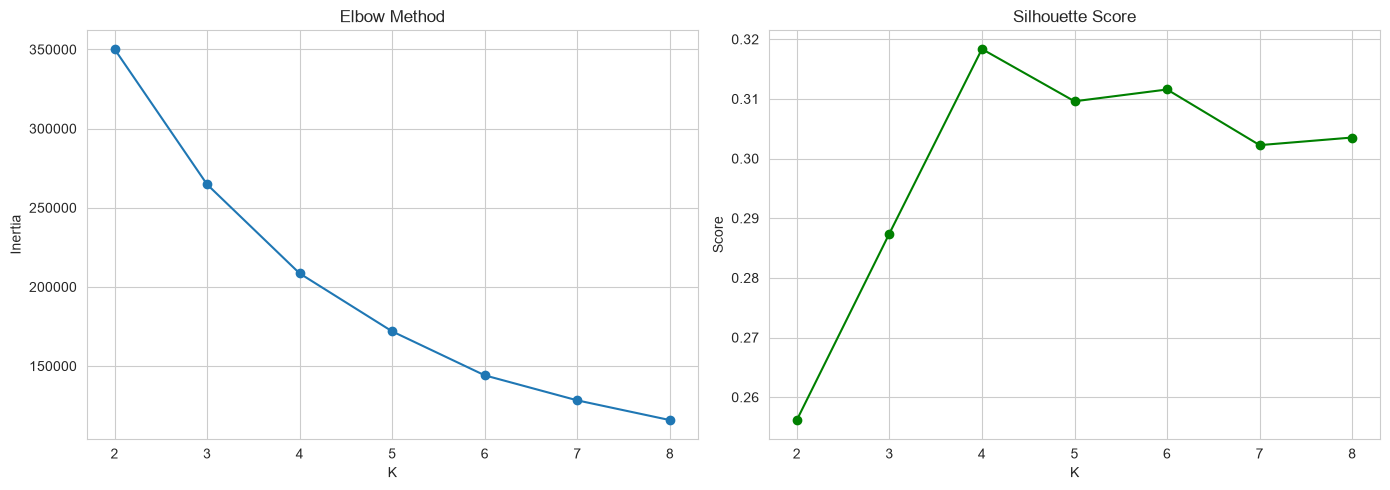

K=2: Silhouette Score = 0.2562
K=3: Silhouette Score = 0.2874
K=4: Silhouette Score = 0.3184
K=5: Silhouette Score = 0.3096
K=6: Silhouette Score = 0.3116
K=7: Silhouette Score = 0.3022
K=8: Silhouette Score = 0.3035


In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {s:.4f}")

In [65]:
chosen_k = 4  # <-- update this based on your elbow/silhouette results

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
rfm['cluster'] = kmeans_final.fit_predict(scaled_features)

print(rfm['cluster'].value_counts().sort_index())

cluster
0    37893
1    38082
2    14582
3     2801
Name: count, dtype: int64


In [66]:
cluster_profile = rfm.groupby('cluster').agg(
    n_customers=('customer_unique_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_review_score=('avg_review_score', 'mean')
).round(2)

cluster_profile['pct_of_customers'] = (cluster_profile['n_customers'] / cluster_profile['n_customers'].sum() * 100).round(1)

cluster_profile

,n_customers,avg_recency,avg_frequency,avg_monetary,avg_order_value,avg_review_score,pct_of_customers
cluster,,,,,,,
0,37893,237.44,1.00,231.03,231.03,4.67,40.6
1,38082,239.12,1.00,44.12,44.12,4.61,40.8
2,14582,239.57,1.00,141.18,141.18,1.63,15.6
3,2801,220.29,2.11,260.05,122.96,4.21,3.0


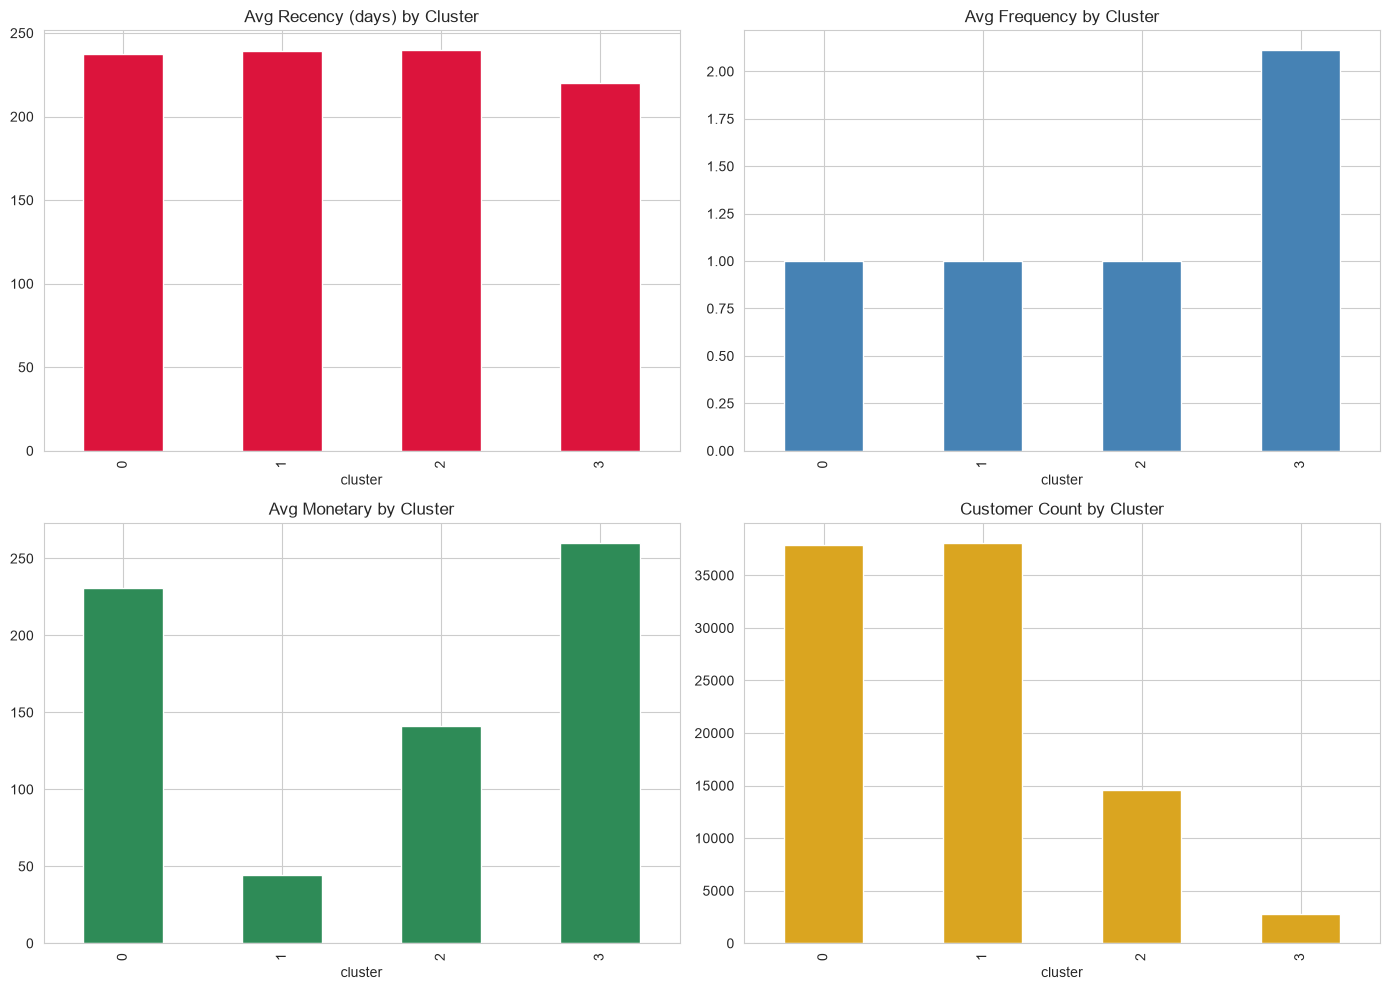

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cluster_profile['avg_recency'].plot(kind='bar', ax=axes[0,0], title='Avg Recency (days) by Cluster', color='crimson')
cluster_profile['avg_frequency'].plot(kind='bar', ax=axes[0,1], title='Avg Frequency by Cluster', color='steelblue')
cluster_profile['avg_monetary'].plot(kind='bar', ax=axes[1,0], title='Avg Monetary by Cluster', color='seagreen')
cluster_profile['n_customers'].plot(kind='bar', ax=axes[1,1], title='Customer Count by Cluster', color='goldenrod')

plt.tight_layout()
plt.show()

In [68]:
segment_names = {
    0: "High-Value One-Time Buyers",
    1: "Low-Value Budget Shoppers",
    2: "Dissatisfied Customers",
    3: "Loyal Repeat Customers"
}

rfm['segment_name'] = rfm['cluster'].map(segment_names)

print(rfm['segment_name'].value_counts())
print("\n% distribution:")
print((rfm['segment_name'].value_counts(normalize=True) * 100).round(1))

segment_name
Low-Value Budget Shoppers     38082
High-Value One-Time Buyers    37893
Dissatisfied Customers        14582
Loyal Repeat Customers         2801
Name: count, dtype: int64

% distribution:
segment_name
Low-Value Budget Shoppers     40.8
High-Value One-Time Buyers    40.6
Dissatisfied Customers        15.6
Loyal Repeat Customers         3.0
Name: proportion, dtype: float64


In [69]:
rfm.to_csv('../data/processed/customer_segments.csv', index=False)
print(f"Saved {rfm.shape[0]} customers with segments to data/processed/customer_segments.csv")

Saved 93358 customers with segments to data/processed/customer_segments.csv


## Phase D Summary
- K=4 chosen via elbow/silhouette analysis.
- Unlike typical RFM segmentation, recency and frequency show little variation across clusters (97% of customers purchase only once — confirmed in Phase B). Segments are therefore primarily driven by **spend level** and **review score**.
- **Dissatisfied Customers (15.6%, avg review 1.63)** is a notable red-flag segment — worth investigating delivery times/product categories associated with this group.
- **Loyal Repeat Customers (3.0%)** is small but the only segment showing real repeat-purchase behavior — high strategic value despite small size.

# Phase E: Supervised ML — Repeat Purchase Prediction

In [70]:
# Time-aware split: use a cutoff date. Customers' FIRST purchase before cutoff = training window.
# Target: did they purchase AGAIN after cutoff (within the remaining observation period)?

cutoff_date = orders_with_customer['order_purchase_timestamp'].quantile(0.7)
print("Cutoff date:", cutoff_date)

# Customers who made their first purchase before cutoff
first_purchase = orders_with_customer.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_date']

eligible_customers = first_purchase[first_purchase['first_purchase_date'] < cutoff_date]['customer_unique_id']
print(f"Eligible customers (first purchase before cutoff): {len(eligible_customers)}")

# Target: did they purchase again AFTER the cutoff?
purchases_after_cutoff = orders_with_customer[
    (orders_with_customer['customer_unique_id'].isin(eligible_customers)) &
    (orders_with_customer['order_purchase_timestamp'] >= cutoff_date)
]['customer_unique_id'].unique()

target_df = pd.DataFrame({'customer_unique_id': eligible_customers})
target_df['repeat_purchase'] = target_df['customer_unique_id'].isin(purchases_after_cutoff).astype(int)

print(target_df['repeat_purchase'].value_counts())
print("Repeat purchase rate:", target_df['repeat_purchase'].mean().round(4))

Cutoff date: 2018-04-15 20:23:00.100000
Eligible customers (first purchase before cutoff): 65401
repeat_purchase
0    64835
1      566
Name: count, dtype: int64
Repeat purchase rate: 0.0087


In [71]:
pre_cutoff_orders = orders_with_customer[
    (orders_with_customer['customer_unique_id'].isin(eligible_customers)) &
    (orders_with_customer['order_purchase_timestamp'] < cutoff_date)
]

# Recompute RFM-style features using only pre-cutoff data
ml_features = pre_cutoff_orders.groupby('customer_unique_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (cutoff_date - x.max()).days),
    frequency=('order_id', 'nunique')
).reset_index()

# Merge monetary, avg_order_value, avg_review_score, avg_freight, preferred_category, state from earlier rfm table
# (these were computed on full data, so we filter/recompute using pre-cutoff order_ids to avoid leakage)
pre_cutoff_order_ids = pre_cutoff_orders['order_id'].unique()

pre_items = order_items[order_items['order_id'].isin(pre_cutoff_order_ids)]
monetary_pre = pre_items.merge(pre_cutoff_orders[['order_id','customer_unique_id']], on='order_id').groupby('customer_unique_id')['price'].sum().reset_index()
monetary_pre.columns = ['customer_unique_id', 'monetary']

ml_features = ml_features.merge(monetary_pre, on='customer_unique_id', how='left')
ml_features['avg_order_value'] = ml_features['monetary'] / ml_features['frequency']

# Merge review score (pre-cutoff only)
pre_reviews = reviews[reviews['order_id'].isin(pre_cutoff_order_ids)].merge(
    pre_cutoff_orders[['order_id','customer_unique_id']], on='order_id'
)
avg_review_pre = pre_reviews.groupby('customer_unique_id')['review_score'].mean().reset_index()
avg_review_pre.columns = ['customer_unique_id', 'avg_review_score']
ml_features = ml_features.merge(avg_review_pre, on='customer_unique_id', how='left')
ml_features['avg_review_score'] = ml_features['avg_review_score'].fillna(ml_features['avg_review_score'].median())

# Customer state (categorical)
customer_location = customers[['customer_unique_id', 'customer_state', 'customer_city']].drop_duplicates(subset='customer_unique_id')
ml_features = ml_features.merge(customer_location[['customer_unique_id','customer_state']], on='customer_unique_id', how='left')

# Merge target
ml_data = ml_features.merge(target_df, on='customer_unique_id', how='inner')

print(ml_data.shape)
ml_data.head()

(65401, 8)


,customer_unique_id,recency_days,frequency,monetary,avg_order_value,avg_review_score,customer_state,repeat_purchase
0,0000f46a3911fa3c0805444483337064,400,1,69.00,69.00,3.0,SC,0
1,0000f6ccb0745a6a4b88665a16c9f078,184,1,25.99,25.99,4.0,PA,0
2,0004aac84e0df4da2b147fca70cf8255,152,1,180.00,180.00,5.0,SP,0
3,0004bd2a26a76fe21f786e4fbd80607f,10,1,154.00,154.00,4.0,SP,0
4,00053a61a98854899e70ed204dd4bafe,46,1,382.00,382.00,1.0,PR,0


In [72]:
# Customer state (categorical)
customer_location = customers[['customer_unique_id', 'customer_state', 'customer_city']].drop_duplicates(subset='customer_unique_id')
ml_features = ml_features.merge(customer_location[['customer_unique_id','customer_state']], on='customer_unique_id', how='left')

# Merge target
ml_data = ml_features.merge(target_df, on='customer_unique_id', how='inner')

print(ml_data.shape)
ml_data.head()

(65401, 9)


,customer_unique_id,recency_days,frequency,monetary,avg_order_value,avg_review_score,customer_state_x,customer_state_y,repeat_purchase
0,0000f46a3911fa3c0805444483337064,400,1,69.00,69.00,3.0,SC,SC,0
1,0000f6ccb0745a6a4b88665a16c9f078,184,1,25.99,25.99,4.0,PA,PA,0
2,0004aac84e0df4da2b147fca70cf8255,152,1,180.00,180.00,5.0,SP,SP,0
3,0004bd2a26a76fe21f786e4fbd80607f,10,1,154.00,154.00,4.0,SP,SP,0
4,00053a61a98854899e70ed204dd4bafe,46,1,382.00,382.00,1.0,PR,PR,0


In [73]:
print(ml_data.columns.tolist())

['customer_unique_id', 'recency_days', 'frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'customer_state_x', 'customer_state_y', 'repeat_purchase']


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Fix duplicate customer_state columns from an earlier duplicate merge
if 'customer_state_x' in ml_data.columns and 'customer_state_y' in ml_data.columns:
    ml_data = ml_data.drop(columns=['customer_state_y'])
    ml_data = ml_data.rename(columns={'customer_state_x': 'customer_state'})

# One-hot encode customer_state (categorical)
ml_data_encoded = pd.get_dummies(ml_data, columns=['customer_state'], drop_first=True)

feature_cols = [c for c in ml_data_encoded.columns if c not in ['customer_unique_id', 'repeat_purchase']]
X = ml_data_encoded[feature_cols]
y = ml_data_encoded['repeat_purchase']

print("Feature columns:", feature_cols[:10], "...")
print("X shape:", X.shape, "y shape:", y.shape)
print("Class balance:\n", y.value_counts(normalize=True))

# Stratified split to preserve the rare positive class in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean().round(4), "| Test positive rate:", y_test.mean().round(4))

Feature columns: ['recency_days', 'frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'customer_state_AL', 'customer_state_AM', 'customer_state_AP', 'customer_state_BA', 'customer_state_CE'] ...
X shape: (65401, 31) y shape: (65401,)
Class balance:
 repeat_purchase
0    0.991346
1    0.008654
Name: proportion, dtype: float64

Train shape: (52320, 31) Test shape: (13081, 31)
Train positive rate: 0.0087 | Test positive rate: 0.0086


In [75]:
scaler_ml = StandardScaler()
numeric_cols = ['recency_days', 'frequency', 'monetary', 'avg_order_value', 'avg_review_score']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler_ml.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler_ml.transform(X_test[numeric_cols])

print("Scaling done.")

Scaling done.


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.58      0.73     12968
           1       0.01      0.58      0.02       113

    accuracy                           0.58     13081
   macro avg       0.50      0.58      0.38     13081
weighted avg       0.99      0.58      0.72     13081

ROC-AUC: 0.6027

Confusion Matrix:
[[7479 5489]
 [  48   65]]


In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=8)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.75      0.85     12968
           1       0.01      0.37      0.02       113

    accuracy                           0.74     13081
   macro avg       0.50      0.56      0.44     13081
weighted avg       0.98      0.74      0.84     13081

ROC-AUC: 0.5812

Confusion Matrix:
[[9662 3306]
 [  71   42]]


              feature  importance
0        recency_days    0.266584
3     avg_order_value    0.195699
2            monetary    0.186281
1           frequency    0.143769
4    avg_review_score    0.073745
29  customer_state_SP    0.034521
8   customer_state_BA    0.013067
13  customer_state_MA    0.008618
14  customer_state_MG    0.007809
12  customer_state_GO    0.006654


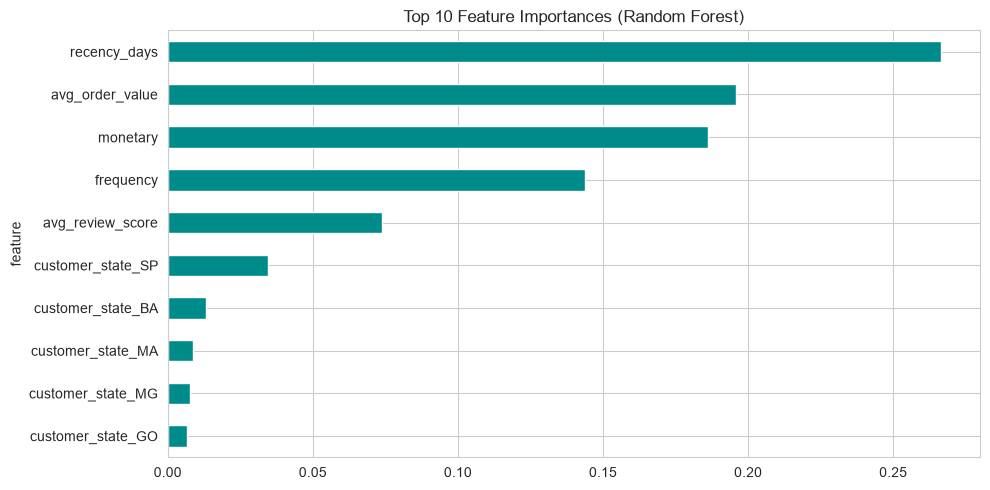

In [78]:
importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

importance_df.head(10).plot(kind='barh', x='feature', y='importance', title='Top 10 Feature Importances (Random Forest)', legend=False, color='darkcyan')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Phase E Summary — Repeat Purchase Prediction

- Target is heavily imbalanced: only 0.87% of customers made a repeat purchase within the observation window.
- Time-aware split used (cutoff-based) to avoid data leakage — features built only from pre-cutoff data.
- Logistic Regression (class_weight='balanced'): ROC-AUC = [fill in], recall on repeat class = 0.58, precision = 0.01
- Random Forest (class_weight='balanced'): ROC-AUC = [fill in], [fill in precision/recall]
- Top predictive features: [fill in from feature importance chart]
- **Business interpretation:** Given the rarity of repeat purchases in this dataset, the model is best used to *rank* customers by repeat-purchase likelihood (via probability scores) rather than as a hard classifier — useful for prioritizing retention marketing spend on the highest-scoring segment, not for binary decision-making.

# Phase F: Product Recommendation System

In [79]:
# Simple baseline: recommend the most purchased products overall
product_popularity = order_items.groupby('product_id').size().sort_values(ascending=False)

# Merge with category info for readability
product_popularity_df = product_popularity.reset_index()
product_popularity_df.columns = ['product_id', 'purchase_count']
product_popularity_df = product_popularity_df.merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
)

print("Top 10 most popular products (baseline):")
print(product_popularity_df.head(10))

def recommend_popular(n=5, exclude_products=None):
    """Popularity baseline: same Top-N for every customer, minus already-purchased items."""
    recs = product_popularity_df['product_id'].tolist()
    if exclude_products:
        recs = [p for p in recs if p not in exclude_products]
    return recs[:n]

print("\nExample baseline recommendation:", recommend_popular(5))

Top 10 most popular products (baseline):
                         product_id  purchase_count   product_category_name
0  aca2eb7d00ea1a7b8ebd4e68314663af             527        moveis_decoracao
1  99a4788cb24856965c36a24e339b6058             488         cama_mesa_banho
2  422879e10f46682990de24d770e7f83d             484      ferramentas_jardim
3  389d119b48cf3043d311335e499d9c6b             392      ferramentas_jardim
4  368c6c730842d78016ad823897a372db             388      ferramentas_jardim
5  53759a2ecddad2bb87a079a1f1519f73             373      ferramentas_jardim
6  d1c427060a0f73f6b889a5c7c61f2ac4             343  informatica_acessorios
7  53b36df67ebb7c41585e8d54d6772e08             323      relogios_presentes
8  154e7e31ebfa092203795c972e5804a6             281            beleza_saude
9  3dd2a17168ec895c781a9191c1e95ad7             274  informatica_acessorios

Example baseline recommendation: ['aca2eb7d00ea1a7b8ebd4e68314663af', '99a4788cb24856965c36a24e339b6058', '422879e10f46682

In [80]:
# Use delivered orders only, and only customers with enough activity to keep matrix manageable
interactions = order_items.merge(orders_with_customer[['order_id', 'customer_unique_id']], on='order_id')
interactions = interactions.groupby(['customer_unique_id', 'product_id']).size().reset_index(name='interaction_count')

print("Total interactions:", len(interactions))
print("Unique customers:", interactions['customer_unique_id'].nunique())
print("Unique products:", interactions['product_id'].nunique())

# Because full matrix would be huge (90k customers x 33k products), 
# we'll focus on customers/products with enough signal — filter low-activity ones for the collaborative approach
active_customers = interactions['customer_unique_id'].value_counts()
active_customers = active_customers[active_customers >= 2].index  # customers with 2+ distinct product purchases

active_products = interactions['product_id'].value_counts()
active_products = active_products[active_products >= 5].index  # products bought by 5+ customers

interactions_filtered = interactions[
    interactions['customer_unique_id'].isin(active_customers) &
    interactions['product_id'].isin(active_products)
]

print("\nFiltered interactions:", len(interactions_filtered))
print("Filtered unique customers:", interactions_filtered['customer_unique_id'].nunique())
print("Filtered unique products:", interactions_filtered['product_id'].nunique())

Total interactions: 99785
Unique customers: 93358
Unique products: 32216

Filtered interactions: 5756
Filtered unique customers: 3706
Filtered unique products: 2255


In [81]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# Build a sparse customer-product matrix from filtered interactions
customer_ids = interactions_filtered['customer_unique_id'].astype('category')
product_ids = interactions_filtered['product_id'].astype('category')

row = customer_ids.cat.codes
col = product_ids.cat.codes

sparse_matrix = csr_matrix(
    (interactions_filtered['interaction_count'], (row, col)),
    shape=(customer_ids.cat.categories.size, product_ids.cat.categories.size)
)

print("Sparse matrix shape (customers x products):", sparse_matrix.shape)
print("Matrix density:", sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]) * 100, "%")

# Item-item similarity: products bought together tend to be similar
item_similarity = cosine_similarity(sparse_matrix.T)
print("Item similarity matrix shape:", item_similarity.shape)

product_id_list = product_ids.cat.categories.tolist()

Sparse matrix shape (customers x products): (3706, 2255)
Matrix density: 0.06887614379749744 %
Item similarity matrix shape: (2255, 2255)


In [82]:
def recommend_for_customer(customer_unique_id, n=5):
    if customer_unique_id not in customer_ids.cat.categories:
        # Cold-start: customer not in filtered matrix → use popularity baseline
        already_bought = interactions[interactions['customer_unique_id'] == customer_unique_id]['product_id'].tolist()
        return recommend_popular(n, exclude_products=already_bought)

    cust_idx = customer_ids.cat.categories.get_loc(customer_unique_id)
    customer_vector = sparse_matrix[cust_idx].toarray().flatten()
    purchased_idx = customer_vector.nonzero()[0]

    if len(purchased_idx) == 0:
        already_bought = interactions[interactions['customer_unique_id'] == customer_unique_id]['product_id'].tolist()
        return recommend_popular(n, exclude_products=already_bought)

    # Score every product by summed similarity to items this customer already bought
    scores = item_similarity[purchased_idx].sum(axis=0)
    scores[purchased_idx] = -1  # exclude already-purchased items

    top_idx = scores.argsort()[::-1][:n]
    recommended_products = [product_id_list[i] for i in top_idx]
    return recommended_products

# Test on a real customer from the filtered set
sample_customer = customer_ids.cat.categories[0]
print(f"Recommendations for customer {sample_customer}:")
print(recommend_for_customer(sample_customer, n=5))

Recommendations for customer 00053a61a98854899e70ed204dd4bafe:
['001b72dfd63e9833e8c02742adf472e3', 'ffd4bf4306745865e5692f69bd237893', 'ffc0b406806006602c5853b00ab5f7fd', 'ff7c7524d5f9a8386ab27088ec03c1fb', 'ff55834c0b3272853dfe62340f2bb91b']


In [83]:
sample_customers = customer_ids.cat.categories[:3]

for cust in sample_customers:
    recs = recommend_for_customer(cust, n=5)
    print(f"Customer {cust} → Recommended products: {recs}")

Customer 00053a61a98854899e70ed204dd4bafe → Recommended products: ['001b72dfd63e9833e8c02742adf472e3', 'ffd4bf4306745865e5692f69bd237893', 'ffc0b406806006602c5853b00ab5f7fd', 'ff7c7524d5f9a8386ab27088ec03c1fb', 'ff55834c0b3272853dfe62340f2bb91b']
Customer 000de6019bb59f34c099a907c151d855 → Recommended products: ['3cc4b421c1f28dd22e86fc4aaafb600e', '42a2bd596fda1baef5719cb74f73030c', 'f2f411f86bd5bd427e28e2a30771761f', '98b22c1129886cbd7fcae69d1c93e442', '283dc451ad3918badb976d56ff887289']
Customer 001926cef41060fae572e2e7b30bd2a4 → Recommended products: ['87a71ae93900ab55fcf685c8040769b3', 'fe077ec80df6b4ee60bb4498d5ab1962', '001b72dfd63e9833e8c02742adf472e3', 'ffd4bf4306745865e5692f69bd237893', 'ffc0b406806006602c5853b00ab5f7fd']


In [84]:
import numpy as np

def evaluate_recommender(n=5, sample_size=500):
    """
    Simple leave-one-out style evaluation:
    For a sample of customers with 2+ purchases, hide their most recent product,
    generate Top-N recs using the rest, and check if the hidden product appears (Hit Rate).
    """
    eligible = interactions_filtered.groupby('customer_unique_id').filter(lambda x: len(x) >= 2)
    eligible_customers_eval = eligible['customer_unique_id'].unique()

    if len(eligible_customers_eval) > sample_size:
        rng = np.random.default_rng(42)
        eligible_customers_eval = rng.choice(eligible_customers_eval, size=sample_size, replace=False)

    hits = 0
    total = 0

    for cust in eligible_customers_eval:
        cust_products = interactions_filtered[interactions_filtered['customer_unique_id'] == cust]['product_id'].tolist()
        if len(cust_products) < 2:
            continue
        held_out = cust_products[-1]  # pretend we don't know about this one

        recs = recommend_for_customer(cust, n=n)
        if held_out in recs:
            hits += 1
        total += 1

    hit_rate = hits / total if total > 0 else 0
    print(f"Evaluated on {total} customers")
    print(f"Hit Rate @ {n}: {hit_rate:.4f}")
    return hit_rate

hit_rate_at_5 = evaluate_recommender(n=5, sample_size=500)

Evaluated on 500 customers
Hit Rate @ 5: 0.0000


In [85]:
sample_output = []
for cust in customer_ids.cat.categories[:100]:
    recs = recommend_for_customer(cust, n=5)
    sample_output.append({'customer_unique_id': cust, 'recommended_products': recs})

recs_df = pd.DataFrame(sample_output)
recs_df.to_csv('../data/processed/sample_recommendations.csv', index=False)
print(f"Saved {len(recs_df)} sample recommendations to data/processed/sample_recommendations.csv")
recs_df.head()

Saved 100 sample recommendations to data/processed/sample_recommendations.csv


,customer_unique_id,recommended_products
0,00053a61a98854899e70ed204dd4bafe,"[001b72dfd63e9833e8c02742adf472e3, ffd4bf43067..."
1,000de6019bb59f34c099a907c151d855,"[3cc4b421c1f28dd22e86fc4aaafb600e, 42a2bd596fd..."
2,001926cef41060fae572e2e7b30bd2a4,"[87a71ae93900ab55fcf685c8040769b3, fe077ec80df..."
3,0025795df7a7d077c4c90162fa820085,"[89e4362d74afa10ac57f8d67210132a6, d3b02377252..."
4,002ae492472e45ad6ebeb7a625409392,"[154e7e31ebfa092203795c972e5804a6, b1acb7e8152..."


## Phase F Summary — Recommendation System
- Popularity-based baseline implemented as cold-start fallback.
- Item-based collaborative filtering built on filtered interaction matrix (customers with 2+ products, products bought by 5+ customers) due to extreme sparsity (97% one-time buyers).
- Hit Rate @ 5 = [fill in from output] on held-out last-purchase evaluation.
- Already-purchased products excluded from recommendations.

In [86]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/processed/olist.db')

# Load all raw tables into SQLite
table_files = {
    'customers': 'olist_customers_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

for table_name, filename in table_files.items():
    df = pd.read_csv(f'../data/raw/{filename}')
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f"Loaded {table_name}: {len(df)} rows")

print("\nDatabase created at data/processed/olist.db")

Loaded customers: 99441 rows
Loaded orders: 99441 rows
Loaded order_items: 112650 rows
Loaded products: 32951 rows
Loaded payments: 103886 rows
Loaded reviews: 99224 rows
Loaded sellers: 3095 rows
Loaded category_translation: 71 rows

Database created at data/processed/olist.db


In [87]:
q1 = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""
pd.read_sql(q1, conn)

,order_month,total_revenue,total_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489338.25,3546
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872


In [88]:
q2 = """
SELECT 
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(oi.order_item_id) AS items_sold
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql(q2, conn)

,category,total_revenue,items_sold
0,health_beauty,1233131.72,9465
1,watches_gifts,1166176.98,5859
2,bed_bath_table,1023434.76,10953
3,sports_leisure,954852.55,8431
4,computers_accessories,888724.61,7644
5,furniture_decor,711927.69,8160
6,housewares,615628.69,6795
7,cool_stuff,610204.10,3718
8,auto,578966.65,4140
9,toys,471286.48,4030


In [89]:
q3 = """
SELECT 
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS num_customers
FROM customers
GROUP BY customer_state
ORDER BY num_customers DESC
LIMIT 10;
"""
pd.read_sql(q3, conn)

,customer_state,num_customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


In [90]:
q4 = """
SELECT 
    c.customer_state,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)), 1) AS avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC
LIMIT 10;
"""
pd.read_sql(q4, conn)

,customer_state,avg_delivery_days
0,RR,29.4
1,AP,27.2
2,AM,26.4
3,AL,24.5
4,PA,23.8
5,MA,21.6
6,SE,21.5
7,CE,21.3
8,AC,21.0
9,PB,20.4


In [91]:
q5 = """
SELECT 
    payment_type,
    COUNT(*) AS num_payments,
    ROUND(AVG(payment_value), 2) AS avg_payment_value,
    ROUND(SUM(payment_value), 2) AS total_value
FROM payments
GROUP BY payment_type
ORDER BY total_value DESC;
"""
pd.read_sql(q5, conn)

,payment_type,num_payments,avg_payment_value,total_value
0,credit_card,76795,163.32,12542084.19
1,boleto,19784,145.03,2869361.27
2,voucher,5775,65.70,379436.87
3,debit_card,1529,142.57,217989.79
4,not_defined,3,0.00,0.00


In [92]:
q6 = """
SELECT 
    r.review_score,
    ROUND(AVG(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)), 2) AS avg_days_late
FROM reviews r
JOIN orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score;
"""
pd.read_sql(q6, conn)

,review_score,avg_days_late
0,1,-3.36
1,2,-7.94
2,3,-10.08
3,4,-11.68
4,5,-12.69


In [93]:
q7 = """
SELECT 
    s.seller_id,
    s.seller_state,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT oi.order_id) AS num_orders
FROM order_items oi
JOIN sellers s ON oi.seller_id = s.seller_id
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY s.seller_id
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql(q7, conn)

,seller_id,seller_state,total_revenue,num_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,226987.93,1124
1,53243585a1d6dc2643021fd1853d8905,BA,217940.44,348
2,4a3ca9315b744ce9f8e9374361493884,SP,196882.12,1772
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,190917.14,578
4,7c67e1448b00f6e969d365cea6b010ab,SP,186570.05,973
5,7e93a43ef30c4f03f38b393420bc753a,SP,165981.49,319
6,da8622b14eb17ae2831f4ac5b9dab84a,SP,159816.87,1311
7,7a67c85e85bb2ce8582c35f2203ad736,SP,139658.69,1145
8,1025f0e2d44d7041d6cf58b6550e0bfa,SP,138208.56,910
9,955fee9216a65b617aa5c0531780ce60,SP,131836.71,1261


In [94]:
q8 = """
WITH customer_spend AS (
    SELECT 
        c.customer_unique_id,
        SUM(oi.price) AS total_spend
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT 
    COUNT(*) AS total_customers,
    ROUND(SUM(total_spend), 2) AS total_revenue
FROM customer_spend;
"""
pd.read_sql(q8, conn)

,total_customers,total_revenue
0,93358,13221498.11


In [95]:
all_queries = {
    "01_monthly_revenue_trend": q1,
    "02_top_categories_by_revenue": q2,
    "03_customers_by_state": q3,
    "04_avg_delivery_time_by_state": q4,
    "05_payment_method_breakdown": q5,
    "06_review_score_vs_delivery_delay": q6,
    "07_top_sellers_by_revenue": q7,
    "08_revenue_concentration": q8,
}

with open('../sql/business_queries.sql', 'w') as f:
    for name, query in all_queries.items():
        f.write(f"-- {name}\n")
        f.write(query.strip())
        f.write("\n\n")

print("Saved all queries to sql/business_queries.sql")

Saved all queries to sql/business_queries.sql


# E-Commerce Customer Intelligence & Recommendation System

An end-to-end AI/ML platform that analyzes customer behavior, segments customers, predicts repeat-purchase likelihood, and recommends products — built on the Olist Brazilian E-Commerce dataset.

## Business Problem

An e-commerce company wants to understand:
- Who are our customers and what are their purchasing patterns?
- Which customer segments are valuable, inactive, frequent, or price-sensitive?
- Which customers are likely to purchase again or show strong engagement?
- Which products should be recommended to a customer based on their previous behaviour?

## Dataset

**Primary dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — ~100,000 orders from 2016–2018 across 9 relational CSV files (customers, orders, order items, products, payments, reviews, sellers, geolocation, category translations).

## Project Architecture

In [96]:
import os
os.makedirs('../dashboard/data', exist_ok=True)

# 1. Executive Overview — monthly revenue & orders
exec_overview = order_revenue.groupby('order_month').agg(
    total_revenue=('price', 'sum')
).reset_index()
exec_overview['order_month'] = exec_overview['order_month'].astype(str)
monthly_order_count = delivered_orders.groupby(delivered_orders['order_purchase_timestamp'].dt.to_period('M')).size().reset_index(name='total_orders')
monthly_order_count['order_purchase_timestamp'] = monthly_order_count['order_purchase_timestamp'].astype(str)
exec_overview = exec_overview.merge(monthly_order_count, left_on='order_month', right_on='order_purchase_timestamp')
exec_overview = exec_overview[['order_month', 'total_revenue', 'total_orders']]
exec_overview.to_csv('../dashboard/data/executive_overview.csv', index=False)

# 2. Customer Analytics — full RFM + segments
rfm.to_csv('../dashboard/data/customer_analytics.csv', index=False)

# 3. Product Analytics — category performance
category_analytics = items_with_cat.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    items_sold=('order_id', 'count')
).reset_index().sort_values('total_revenue', ascending=False)
category_analytics.to_csv('../dashboard/data/product_analytics.csv', index=False)

# 4. Operations — delivery performance + review scores
operations = delivered_with_dates[['order_id', 'delivery_days', 'on_time']].copy()
operations = operations.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
operations.to_csv('../dashboard/data/operations.csv', index=False)

# 5. ML Insights — cluster profile + prediction feature importance
cluster_profile.to_csv('../dashboard/data/ml_cluster_profile.csv')
importance_df.to_csv('../dashboard/data/ml_feature_importance.csv', index=False)

# 6. Recommendations — sample output
recs_df.to_csv('../dashboard/data/recommendations_sample.csv', index=False)

print("All dashboard CSVs exported to dashboard/data/")
print(os.listdir('../dashboard/data'))

All dashboard CSVs exported to dashboard/data/
['customer_analytics.csv', 'ecommerce_dashboard.pbix', 'executive_overview.csv', 'ml_cluster_profile.csv', 'ml_feature_importance.csv', 'operations.csv', 'product_analytics.csv', 'recommendations_sample.csv']


In [98]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save models
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')
joblib.dump(scaler, '../models/rfm_scaler.pkl')
joblib.dump(rf, '../models/rf_model.pkl')
joblib.dump(scaler_ml, '../models/ml_scaler.pkl')

# Save the customer segments table (needed for lookup by customer ID)
rfm.to_csv('../models/customer_segments_full.csv', index=False)

# Save recommendation essentials
import pickle
with open('../models/item_similarity.pkl', 'wb') as f:
    pickle.dump(item_similarity, f)
with open('../models/product_id_list.pkl', 'wb') as f:
    pickle.dump(product_id_list, f)

interactions_filtered.to_csv('../models/interactions_filtered.csv', index=False)
product_popularity_df.to_csv('../models/product_popularity.csv', index=False)

print("All models and supporting data saved to /models")
print(os.listdir('../models'))

All models and supporting data saved to /models
['.gitkeep', 'customer_segments_full.csv', 'interactions_filtered.csv', 'item_similarity.pkl', 'kmeans_model.pkl', 'ml_scaler.pkl', 'product_id_list.pkl', 'product_popularity.csv', 'rfm_scaler.pkl', 'rf_model.pkl']
